## Volatility regime detection with Hidden Markov Model ##

### Appendix - What if all vols? ###


Paulo Yoshio Kuga


**Abstract**

In the previous notebook, we used log parkinson as a way to adapt a HMM as representative of our volatility dynamics. But what if we could compare all volatilties?


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import bandeirante as bd
import numpy as np

from scipy.signal import stft

from hmmlearn.hmm import GaussianHMM

import yfinance as yf
import statsmodels.api as sm
from datetime import datetime

Again, we use our yfinance data and calculates all the volatilities, using a window of 21 days. 

In [2]:
start_date = datetime(2016,1,1)
end_date = datetime.today()

ticker = "^BVSP"

dataset = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    interval="1d"
    ).droplevel(axis=1,level=1)

w = 21 #general volatility window

dataset["returns"] = dataset["Close"].pct_change().add(1).apply(np.log).dropna()
dataset["vol_YZ"] = bd.yang_zhang(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open")

dataset["SNR"] = dataset["returns"].rolling(w).mean()/dataset["vol_YZ"]

dataset.dropna(inplace=True) #to assure consistency along the dataset

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

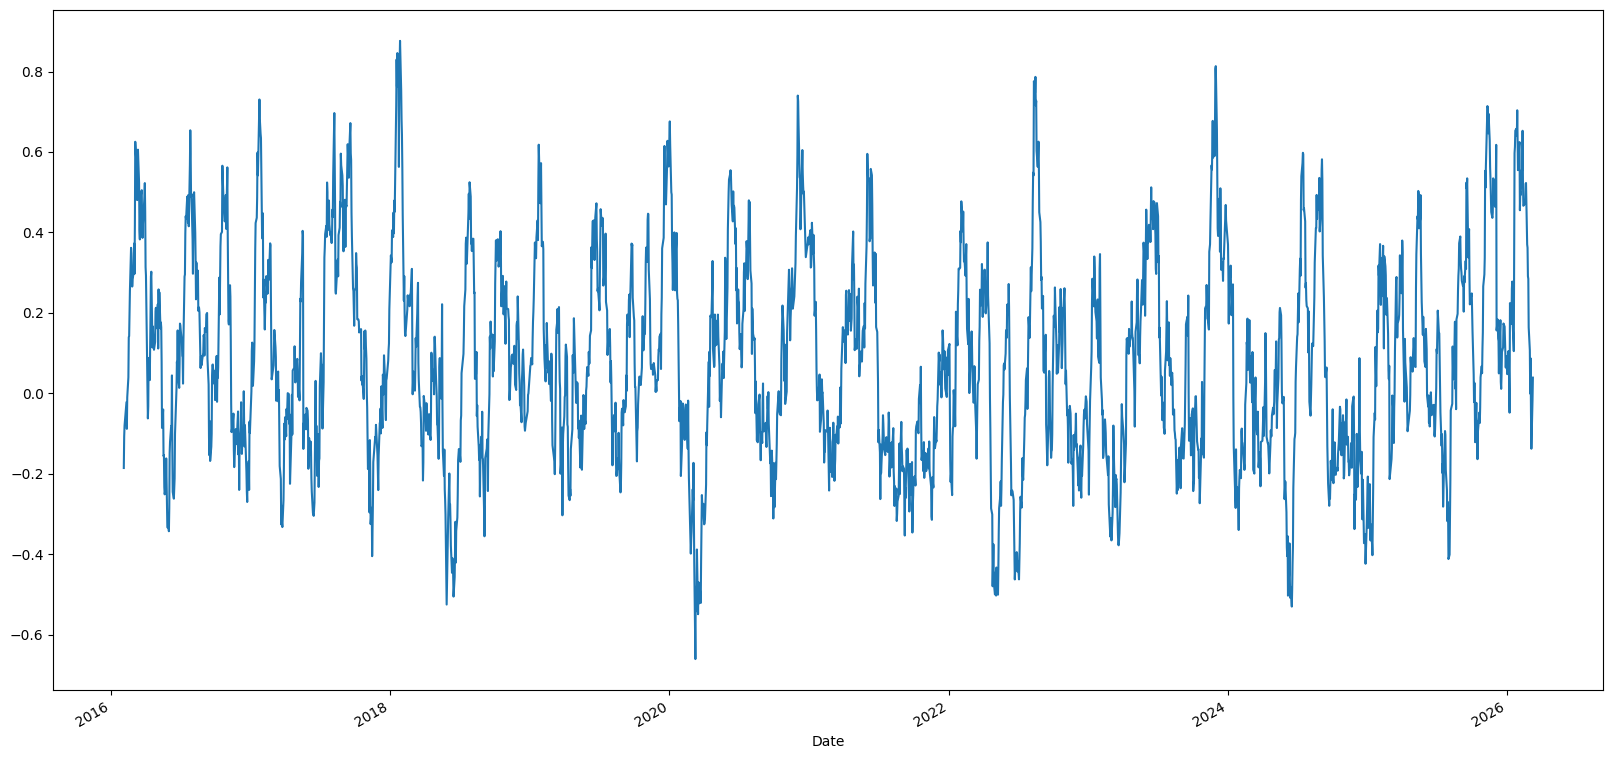

In [3]:
dataset["SNR"].plot(figsize=(20,10))#.hist(bins=30)

We can plot the log-returns and the two types of volatility. It is possible to notice that, usually, Parkinson volatility tends to be more conservative along the time. It is known that statistical standard deviation volatility tends to superestimate volatility true value.

As before, we set our models.

It is possible to observe that YZ vol appears to be the more reasonable model. Peaks are well defined by state 3 and riskier vols are defined by state 2. Moreover it is possible to notice the state 0 would represent the normal vol levels. 

In [4]:
vol_YZ_np = dataset["vol_YZ"]
exog = dataset["returns"].pow(2).ewm(span=w).mean()


markov_model = sm.tsa.MarkovRegression(vol_YZ_np,k_regimes=3,order=2,exog=exog)
resultado = markov_model.fit()

c:\Users\Protocolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Protocolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\Protocolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: xlabel='Date'>

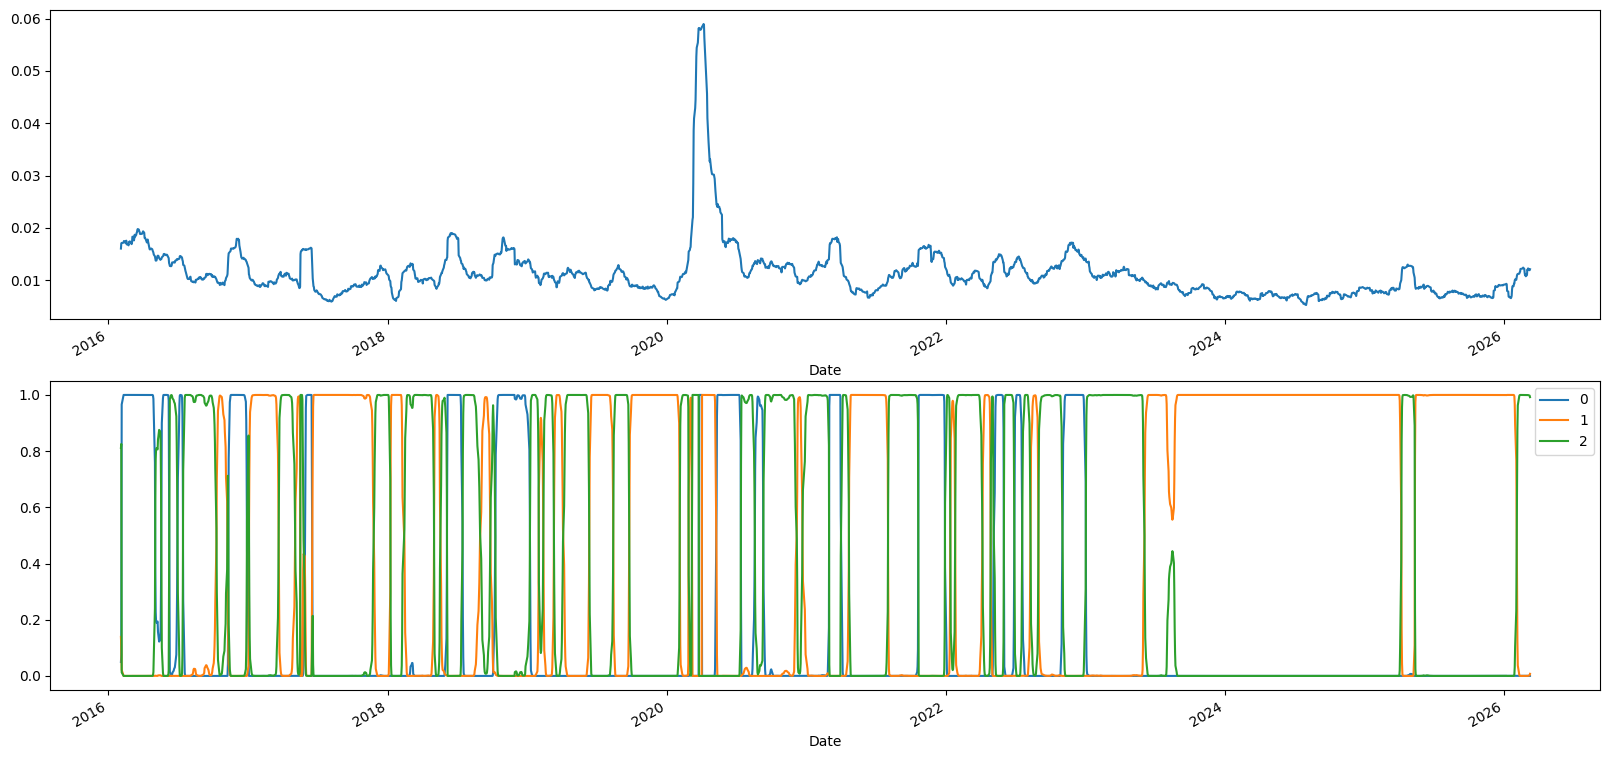

In [5]:
fig,axs = plt.subplots(2,1,figsize=(20,10))

vol_YZ_np.plot(ax=axs[0])
resultado.smoothed_marginal_probabilities.plot(ax=axs[1])

<Axes: >

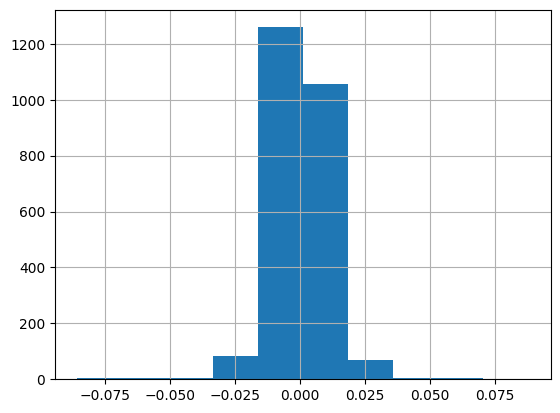

In [6]:
pd.Series(bd.slope(dataset["returns"],w)).hist()